In [1]:
import pandas as pd
import scanpy as sc
import scvelo as scv
import cafe

output_dir = "./output/26.03.20-case_gastrulation_gene_analysis"
img_dir = "./img/26.03.20-case_gastrulation_gene_analysis"

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

In [2]:
# filename = "output/26.02.02-gastrulation_case_data/gastrulation.h5ad"
# fadata = cafe.data.read_h5ad(filename)
# fadata

差异表达计算火山图，标注Feature Importance的Top3基因与对照基因

In [3]:
# 预处理后的差异表达计算
# scv.pp.filter_and_normalize(fadata, min_counts=3, n_top_genes=2000) # normalize and log transform the data, and select highly variable genes
# sc.tl.rank_genes_groups(fadata, groupby="celltype_coarse", groups=["Blood"], method="wilcoxon")
# sc.tl.rank_genes_groups(fadata, groupby="celltype_coarse", groups=["Blood"], method="t-test")
# DE_normalized_df = sc.get.rank_genes_groups_df(fadata, group="Blood") 
# DE_normalized_df.to_csv(f"{output_dir}/DE_normalized_genes_Blood_vs_Others.csv")
DE_normalized_df = pd.read_csv(f"{output_dir}/DE_normalized_genes_Blood_vs_Others.csv", index_col=0)
DE_normalized_df.head() 
# NOTE: too many cells, pvals is zero because of floating underflow, which is also the large cell group effect
# reference: https://single-cell-tutorial.readthedocs.io/zh/latest/stages/4-1/

,names,scores,logfoldchanges,pvals,pvals_adj
0,Lmo2,161.71072,4.982755,0.0,0.0
1,Fth1,148.96753,1.578787,0.0,0.0
2,Car2,139.10641,3.515599,0.0,0.0
3,Cited4,138.55414,7.633902,0.0,0.0
4,Tal1,135.88974,6.351285,0.0,0.0


火山图

In [4]:
feature_imp_df = pd.read_csv("./output/26.03.16-case_gastrulation/feature_importance.csv")
feature_imp_df

,feature_id,importance,gene
0,1133,0.031582,Car2
1,1670,0.030844,Ifitm1
2,1577,0.026399,Hbb-bh1
3,1238,0.025361,Smim1
4,915,0.025122,Fth1
...,...,...,...
1995,774,0.000000,Pdzph1
1996,773,0.000000,Tubb4a
1997,771,0.000000,Rftn1
1998,770,0.000000,Apobec2


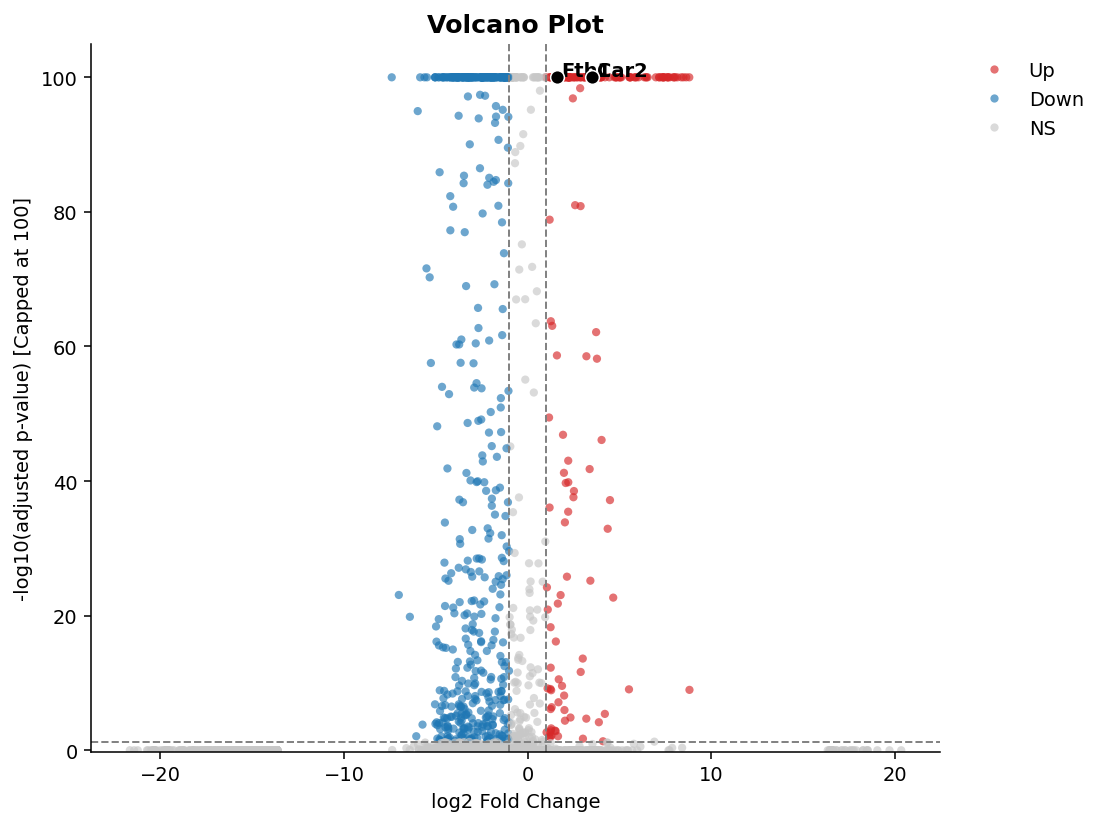

In [5]:
# choose top intersection genes between FeatureIMP and DE to highlight in the volcano plot
topn = 5
# strategy1: directly take the intersection of topn genes from both lists
genes_to_highlight = set(feature_imp_df.loc[:topn, "gene"].to_list()) & set(DE_normalized_df.loc[:topn, "names"].to_list())
# strategy2: take the intersection of all genes, then sort by feature importance and take topn
# intersection_genes = list((set(feature_imp_df["gene"].to_list()) & set(DE_normalized_df["names"].to_list())))
# genes_to_highlight = feature_imp_df.query("gene in @intersection_genes").sort_values("importance", ascending=False).head(topn)["gene"].to_list()

cafe.plot.plot_volcano(
    de_df=DE_normalized_df,
    genes_to_highlight=list(genes_to_highlight),
    max_log_q=100,
    use_padjust=True,
    show_arrow=False,
    save=f"{img_dir}/DE_volcano_(Blood_vs_Others).pdf"
)

富集分析
- Web: 
  - DAVID: https://davidbioinformatics.nih.gov/workspace.html
  - MetaScape: https://metascape.org/gp/#/main/step1
- Python package: gseapy

In [6]:
# 提取富集分析的基因
topn = 50
intersection_genes = list((set(feature_imp_df["gene"].to_list()) & set(DE_normalized_df["names"].to_list())))
genes_to_enrich = feature_imp_df.query("gene in @intersection_genes").sort_values("importance", ascending=False).head(topn)["gene"].to_list()
enrichment_gene_df = DE_normalized_df.query("names in @genes_to_enrich and logfoldchanges > 0")
enrichment_gene_df["names"].to_csv(f"{output_dir}/enrichment_genes.csv", index=False, header=False)

可视化富集分析结果

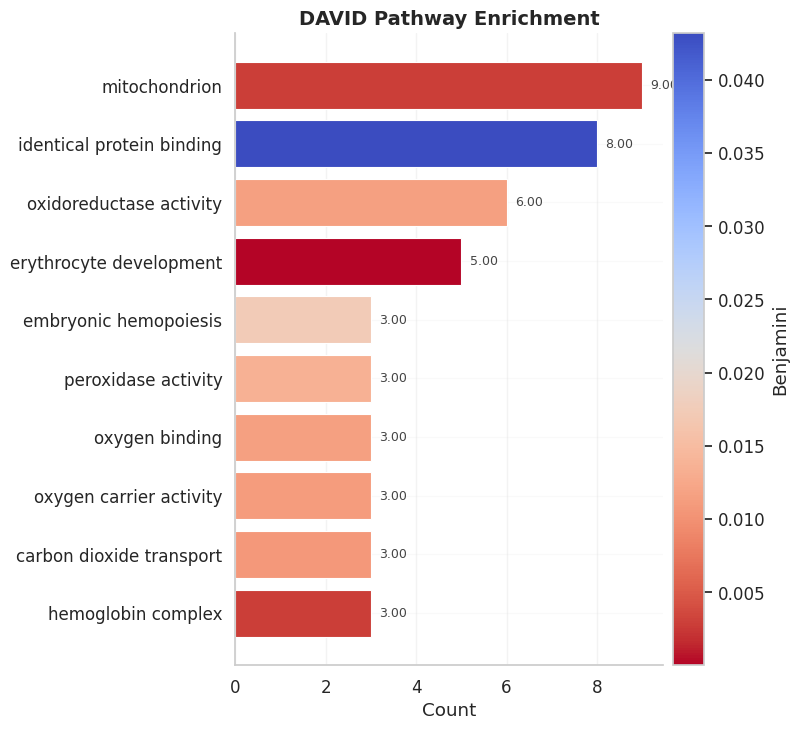

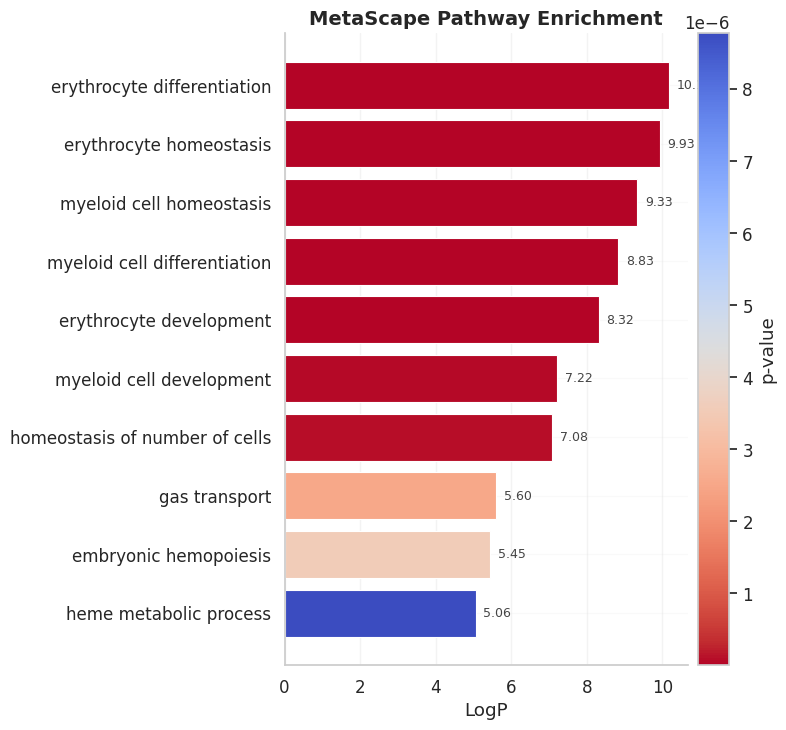

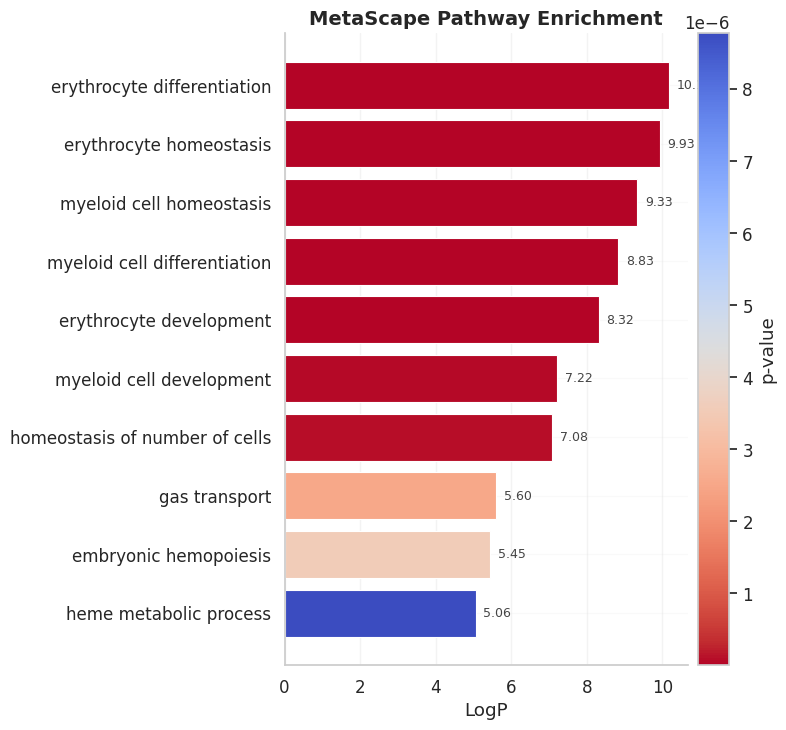

In [10]:
david_enrichment_df = pd.read_csv(f"{output_dir}/enrichment_David.csv")
david_enrichment_df.head()
metascape_enrichment_df = pd.read_csv(f"{output_dir}/enrichment_MetaScape.csv")
metascape_enrichment_df.head()

cafe.plot.plot_enrichment(
    david_enrichment_df,
    method="david",
    top_n=10,
    group=False,
    title="DAVID Pathway Enrichment",
    save_path=f"{img_dir}/enrichment_david_panel.pdf",
)

cafe.plot.plot_enrichment(
    metascape_enrichment_df,
    method="metascape",
    top_n=10,
    group=False,
    title="MetaScape Pathway Enrichment",
    save_path=f"{img_dir}/enrichment_metascape_panel.pdf",
) 

## 解释驱动基因与差异表达基因

线性轨迹上也可以用直接用相关性计算高相关基因，这种简单寻找特征的方式与这里的FeatureImp（审稿人问了的话以后再说）。寻找驱动基因的两种方式

（1）相关性计算

（2）FeatureImp，可以不仅仅在线性轨迹上

（3）TradeSeq待集成